# Bond Valuation (CFA Level 1)

A from-scratch exploration of bond pricing, yield computation, and the price-yield relationship.

**Prerequisites:** basic time-value-of-money concepts, present value.

**Outline**
1. What is a bond?
2. Bond cash flow structure
3. Coupon bond pricing
4. Zero-coupon bonds
5. Accrued interest & day count conventions
6. Clean vs dirty price
7. Yield to maturity (bisection solver)
8. Current yield vs YTM
9. Price-yield relationship
10. Premium / discount / par bonds
11. References

---
## 1. What Is a Bond?

At its simplest, **a bond is a loan that you can buy and sell**.

When a company or government needs money, it can borrow from thousands of investors at once by issuing bonds. Each bond is essentially an IOU that says:

> *"I promise to pay you a fixed amount of interest every six months, and I will return your principal on a specific date in the future."*

### A Real-World Analogy

Imagine you lend your friend $1,000. Your friend promises to:
- Pay you $30 every six months as a "thank you" for the loan (interest)
- Return the full $1,000 after 5 years

That is exactly how a bond works, except the "friend" is a corporation (corporate bond) or a government (government bond / Treasury), and the IOU can be traded in financial markets.

### Key Terminology

| Term | Meaning | Our Analogy |
|------|---------|-------------|
| **Face value** (par value) | The amount repaid at maturity | The $1,000 you lent |
| **Coupon rate** | Annual interest rate on the face value | The agreed "thank you" rate (6% per year) |
| **Coupon payment** | Actual dollar amount paid each period | $30 every six months |
| **Maturity** | When the face value is returned | 5 years from now |
| **Issuer** | The borrower | Your friend / Apple Inc. / US Treasury |
| **Bondholder** | The lender (you, the investor) | You |

> **Key Concept:** Bonds are the largest asset class in the world — larger than the stock market. As of 2024, the global bond market exceeds $130 trillion. Understanding bond valuation is therefore foundational to virtually every area of finance.

### Types of Bonds: A Quick Overview

Before diving into valuation, it helps to know the main categories:

| Type | Issuer | Risk Level | Typical Maturity |
|------|--------|-----------|------------------|
| **Treasury bonds** | US government | Virtually risk-free | 10-30 years |
| **Treasury notes** | US government | Virtually risk-free | 2-10 years |
| **Corporate bonds** | Corporations (Apple, Ford, etc.) | Low to high (depends on credit rating) | 1-30 years |
| **Municipal bonds** | State/local governments | Low to moderate | 1-30+ years |
| **Agency bonds** | Government-sponsored entities (Fannie Mae) | Very low | Various |

Each type has its own risk profile and tax treatment, but the *valuation mechanics* we learn in this notebook apply to all of them.

### Why Do Bonds Exist?

- **For issuers:** Bonds provide a way to raise large amounts of capital, often at lower cost than bank loans.
- **For investors:** Bonds provide predictable income streams and are generally less volatile than stocks.
- **For the economy:** The bond market is where interest rates are "discovered" — it signals what investors think about inflation, growth, and risk.

### The Three Fundamental Questions of Bond Analysis

Everything in this notebook revolves around three questions:

1. **What is this bond worth?** (pricing / valuation)
2. **What return does this bond offer?** (yield measurement)
3. **How does the price change when conditions change?** (price-yield relationship)

Let us begin with the first question by understanding the cash flows that define a bond.

> **CFA Exam Tip:** The CFA curriculum distinguishes between *money market instruments* (maturity < 1 year, e.g., T-bills, commercial paper) and *capital market instruments* (maturity > 1 year, e.g., Treasury notes, corporate bonds). Bond valuation applies to the latter.

---
## 2. Setup

In [1]:
%matplotlib inline
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

ATOL = 1e-10
RTOL = 1e-6

PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'gold'
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3})

---
## 3. Bond Cash Flow Structure

### The Two Types of Cash Flows

A plain-vanilla **coupon bond** promises exactly two types of payments:

1. **Coupon payments** — periodic interest payments, typically every 6 months (semi-annual)
2. **Principal repayment** — the face value, returned at maturity

### The Math

Each coupon payment equals:

$$C = \frac{c \times F}{m}$$

where:
- $C$ = coupon payment per period (dollars)
- $c$ = annual coupon rate (e.g., 0.06 for 6%)
- $F$ = face (par) value (e.g., $1,000)
- $m$ = number of coupon payments per year (2 for semi-annual)

The total number of coupon payments is $N = m \times T$, where $T$ is the number of years to maturity.

### Worked Example: 5-Year, 6% Semi-Annual Bond

Let us work through a concrete example by hand:

- Face value: $F = \$1{,}000$
- Coupon rate: $c = 6\%$ per year
- Frequency: $m = 2$ (semi-annual)
- Maturity: $T = 5$ years

**Step 1:** Calculate the coupon payment:
$$C = \frac{0.06 \times 1{,}000}{2} = \$30$$

**Step 2:** Count the total number of payments:
$$N = 2 \times 5 = 10 \text{ payments}$$

**Step 3:** Write out the cash flow timeline:

```
Time (yrs):  0     0.5    1.0    1.5    2.0    2.5    3.0    3.5    4.0    4.5    5.0
             |      |      |      |      |      |      |      |      |      |      |
Cash flow: -Price  $30    $30    $30    $30    $30    $30    $30    $30    $30   $1,030
                                                                              ($30 coupon
                                                                              + $1,000 par)
```

Notice the last payment is $1,030 — the final coupon ($30) plus the return of face value ($1,000).

> **Key Concept:** The cash flow structure of a bond is completely known at issuance (for fixed-rate bonds). There is no uncertainty about *what* will be paid — only about *whether* the issuer will actually pay (credit risk) and what those future dollars will be *worth* (interest rate risk).

### Another Example: Annual vs Semi-Annual

What if the same bond paid coupons annually instead of semi-annually?

- $C = \frac{0.06 \times 1{,}000}{1} = \$60$ per year
- $N = 1 \times 5 = 5$ payments

You get fewer, larger payments. Most US bonds pay semi-annually, but many European bonds (especially government bonds) pay annually. The math works the same either way.

Let us now generate and visualize these cash flows with code.

In [2]:
def bond_cash_flows(face: float, coupon_rate: float, maturity: int, freq: int = 2) -> tuple:
    """Generate bond cash flow schedule.
    
    Parameters
    ----------
    face : float – par / face value
    coupon_rate : float – annual coupon rate (e.g. 0.05 for 5%)
    maturity : int – years to maturity
    freq : int – coupons per year (2 = semi-annual)
    
    Returns
    -------
    times : ndarray – payment times in years
    cfs : ndarray – cash flows
    """
    n_periods = maturity * freq
    coupon = face * coupon_rate / freq          # C = c * F / m
    times = np.arange(1, n_periods + 1) / freq  # payment dates in years
    cfs = np.full(n_periods, coupon)             # every period gets a coupon
    cfs[-1] += face                              # final period also returns par
    return times, cfs

# Example: 5-year, 6% semi-annual bond, $1000 face
times, cfs = bond_cash_flows(1000, 0.06, 5, 2)
print(f"Payment times (years): {times}")
print(f"Cash flows ($):        {cfs}")

Payment times (years): [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
Cash flows ($):        [  30.   30.   30.   30.   30.   30.   30.   30.   30. 1030.]


The output confirms our hand calculation: nine payments of $30, and a final payment of $1,030 (coupon + par). Let us visualize this as a timeline chart.

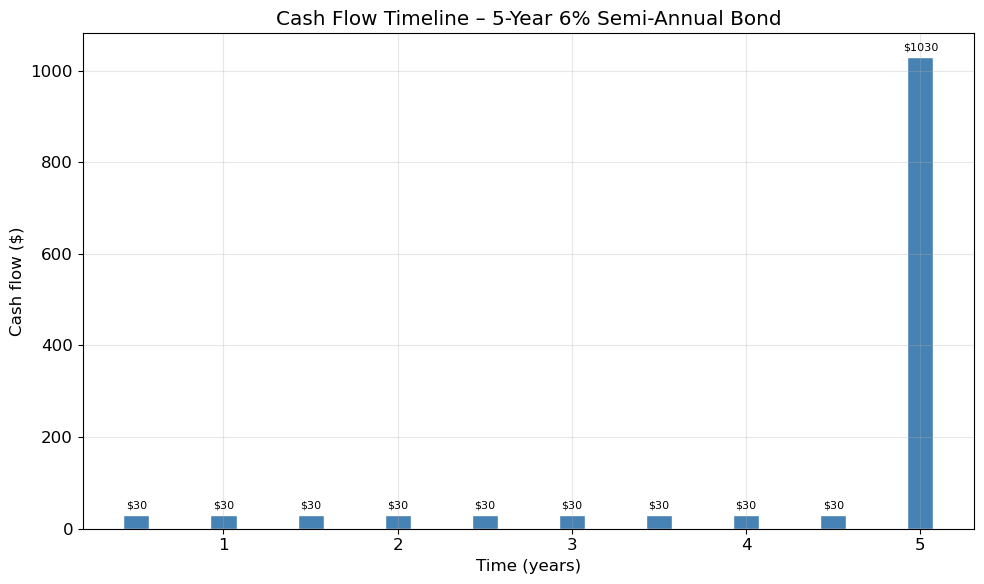

In [3]:
# Visualise the cash-flow timeline
fig, ax = plt.subplots()
ax.bar(times, cfs, width=0.15, color=PRIMARY, edgecolor='white')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Cash flow ($)')
ax.set_title('Cash Flow Timeline – 5-Year 6% Semi-Annual Bond')
for t, cf in zip(times, cfs):
    ax.text(t, cf + 15, f'${cf:.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

The chart clearly shows the "spike" at maturity — that large final bar includes both the last coupon and the return of principal. This is the hallmark cash flow pattern of a bullet bond (as opposed to an amortizing bond, which returns principal gradually).

---
## 4. Coupon Bond Pricing

### The Central Idea: Present Value

Here is the most important idea in bond valuation:

> **Key Concept:** The fair price of a bond is the present value of all its future cash flows. A dollar tomorrow is worth less than a dollar today, so we "discount" each future payment back to the present.

Why is $1 tomorrow worth less than $1 today? Because if you have $1 today, you could invest it and have more than $1 tomorrow. This is the **time value of money**.

### The Discount Rate

To discount future cash flows, we need a rate. For bonds, we use the **yield to maturity (YTM)**, denoted $y$. Think of it as the market's required rate of return for this bond.

If the YTM is 7% per year (compounded semi-annually), then $1 received in 6 months is worth:

$$PV = \frac{\$1}{(1 + 0.07/2)^1} = \frac{\$1}{1.035} = \$0.9662$$

### The Pricing Formula

The **fair price** of a bond is the sum of the present values of all future cash flows:

$$P = \sum_{k=1}^{N} \frac{C}{\left(1 + y/m\right)^k} + \frac{F}{\left(1 + y/m\right)^N}$$

where:
- $P$ = bond price
- $C$ = coupon payment per period
- $F$ = face value
- $y$ = yield to maturity (annual)
- $m$ = compounding frequency per year
- $N$ = total number of periods ($m \times T$)

The first term discounts all the coupon payments; the second term discounts the face value.

Using the **annuity formula** (a shortcut for summing a geometric series), this simplifies to:

$$P = C \cdot \frac{1 - (1+y/m)^{-N}}{y/m} + F \cdot (1+y/m)^{-N}$$

### Worked Example: Price a 5-Year, 6% Bond at 7% YTM

Given: $F = 1{,}000$, $c = 6\%$, $y = 7\%$, $T = 5$, $m = 2$

**Step 1:** Compute inputs:
- $C = 1{,}000 \times 0.06 / 2 = \$30$
- $N = 5 \times 2 = 10$
- $r = y/m = 0.07/2 = 0.035$

**Step 2:** Discount each cash flow (let us show the first few and the last):

| Period $k$ | Time (yrs) | Cash Flow | Discount Factor $\frac{1}{1.035^k}$ | Present Value |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 0.5 | $30 | 0.9662 | $28.99 |
| 2 | 1.0 | $30 | 0.9335 | $28.01 |
| 3 | 1.5 | $30 | 0.9019 | $27.06 |
| ... | ... | ... | ... | ... |
| 10 | 5.0 | $1,030 | 0.7089 | $730.16 |

**Step 3:** Sum all present values:
$$P = 28.99 + 28.01 + 27.06 + \cdots + 730.16 \approx \$958.42$$

The bond trades below par ($1,000) because the market requires 7% but the bond only pays 6%. Investors demand a discount to compensate.

> **CFA Exam Tip:** When the required yield > coupon rate, the bond trades at a **discount**. When yield < coupon rate, it trades at a **premium**. When yield = coupon rate, price = par. This is one of the most tested relationships.

### Quick Sanity Checks

Before moving to code, here are some useful mental checks:

1. If the discount rate is 0%, the bond price should equal the sum of all undiscounted cash flows ($30 x 10 + $1,000 = $1,300).
2. If the discount rate equals the coupon rate (6%), the bond should be priced at exactly par ($1,000).
3. As the discount rate approaches infinity, the bond price approaches $0.

Let us verify this with code, using both the annuity formula and the cash-flow-by-cash-flow approach.

In [4]:
def bond_price(face: float, coupon_rate: float, ytm: float, maturity: int, freq: int = 2) -> float:
    """Price a coupon bond using the closed-form annuity formula."""
    n = maturity * freq                  # total number of periods
    c = face * coupon_rate / freq        # coupon payment per period
    r = ytm / freq                       # periodic discount rate
    if abs(r) < 1e-14:                   # edge case: zero yield
        return c * n + face
    pv_coupons = c * (1 - (1 + r) ** (-n)) / r   # annuity formula for coupons
    pv_par = face * (1 + r) ** (-n)               # PV of face value
    return pv_coupons + pv_par

def bond_price_cf(face, coupon_rate, ytm, maturity, freq=2):
    """Price by discounting individual cash flows (general approach)."""
    times, cfs = bond_cash_flows(face, coupon_rate, maturity, freq)
    r = ytm / freq
    periods = times * freq
    discount_factors = (1 + r) ** (-periods)  # one DF per cash flow
    return np.sum(cfs * discount_factors)

# Verify both give identical answers
p1 = bond_price(1000, 0.06, 0.07, 5, 2)
p2 = bond_price_cf(1000, 0.06, 0.07, 5, 2)
print(f"Annuity formula:  ${p1:.4f}")
print(f"Cash-flow method: ${p2:.4f}")
assert abs(p1 - p2) < ATOL, "Prices should match!"

Annuity formula:  $958.4170
Cash-flow method: $958.4170


Both methods agree, as expected. The annuity formula is simply a mathematical shortcut for summing all the individually discounted cash flows. The price of approximately $958 confirms our hand calculation: the bond trades at a discount because the coupon rate (6%) is below the market yield (7%).

---
## 5. Zero-Coupon Bonds

### What Is a Zero-Coupon Bond?

A **zero-coupon bond** (or "zero") pays no interest along the way. The investor buys it at a discount and receives the face value at maturity. The entire return comes from the price appreciation.

Think of it like buying a $100 gift card for $61.39 today, knowing you can "redeem" it for $100 in 10 years. Your profit is built into the discounted purchase price.

### Why Do Zeros Exist?

Zero-coupon bonds are popular for several reasons:

1. **No reinvestment risk.** Since there are no coupons, you do not need to worry about reinvesting intermediate payments at uncertain future rates.
2. **Perfect for matching liabilities.** If you know you need exactly $100,000 in 10 years (e.g., for a child's college tuition), a zero-coupon bond guarantees that exact amount.
3. **Maximum price sensitivity.** Zeros are the most interest-rate-sensitive bonds for a given maturity, making them useful for speculation or hedging.

### The Formula

Since there are no coupons ($C = 0$), the pricing formula collapses to just the PV of the face value:

$$P_{\text{zero}} = \frac{F}{(1 + y/m)^{N}}$$

### Worked Example: 10-Year Zero at 5%

- $F = 1{,}000$, $y = 5\%$, $T = 10$, $m = 2$ (semi-annual compounding)
- $N = 20$ periods
- $P = \frac{1{,}000}{(1.025)^{20}} = \frac{1{,}000}{1.6386} = \$610.27$

So you pay about $610 today and receive $1,000 in 10 years. The implied annual return is 5%.

> **Key Concept:** Zero-coupon bonds are the fundamental building blocks of fixed income. Any coupon bond can be thought of as a portfolio of zero-coupon bonds — one zero for each cash flow. This insight is the basis for "bootstrapping" a yield curve.

> **CFA Exam Tip:** U.S. Treasury STRIPS (Separate Trading of Registered Interest and Principal Securities) are zero-coupon bonds created by stripping the coupons from Treasury notes and bonds.

In [5]:
def zero_coupon_price(face: float, ytm: float, maturity: float, freq: int = 2) -> float:
    """Price a zero-coupon bond."""
    n = maturity * freq
    return face / (1 + ytm / freq) ** n

# 10-year zero at 5% semi-annual compounding
p_zero = zero_coupon_price(1000, 0.05, 10, 2)
print(f"10-year zero-coupon bond price at 5% YTM: ${p_zero:.2f}")
print(f"Discount factor: {p_zero / 1000:.6f}")

# Verify: a coupon bond with 0% coupon should match
p_check = bond_price(1000, 0.0, 0.05, 10, 2)
assert abs(p_zero - p_check) < ATOL

10-year zero-coupon bond price at 5% YTM: $610.27
Discount factor: 0.610271


The price of $610.27 matches our hand calculation exactly. Notice how the cross-check works: setting the coupon rate to 0% in our general bond pricing function produces the same price as the dedicated zero-coupon formula, confirming consistency.

---
## 6. Accrued Interest & Day Count Conventions

### The Problem: Buying Between Coupon Dates

Suppose a bond pays coupons on January 1 and July 1. You want to buy it on April 1 — that is 90 days after the last coupon. Should the seller just hand over the bond and walk away?

No! The seller held the bond for 3 of the 6 months in this coupon period. She has "earned" half the coupon even though it has not been paid yet. The buyer must compensate her.

This compensation is called **accrued interest**.

### Why Does This Matter?

Without accrued interest, there would be a perverse incentive: everyone would try to buy bonds the day *before* a coupon payment (to capture the coupon) and sell the day *after*. Accrued interest eliminates this gaming by ensuring the economics are fair regardless of when you transact.

### The Formula

$$\text{Accrued Interest} = C \times \frac{\text{Days since last coupon}}{\text{Days in coupon period}}$$

where $C$ is the coupon payment for the period.

### Worked Example

- Bond: 6% semi-annual, $1,000 face value
- Coupon per period: $30
- Days since last coupon: 90
- Days in period: 180

$$\text{AI} = 30 \times \frac{90}{180} = 30 \times 0.5 = \$15.00$$

The buyer pays $15 extra (on top of the quoted price) to compensate the seller.

### Day Count Conventions

How do you count "days"? It depends on the convention used in that market:

| Convention | How it works | Used for |
|-----------|-------------|----------|
| **30/360** | Assumes every month has 30 days, year has 360 | US corporate & municipal bonds |
| **Actual/Actual** | Uses the actual number of calendar days | US Treasuries |
| **Actual/360** | Actual days elapsed, but assumes 360-day year | Money market instruments |
| **Actual/365** | Actual days, 365-day year | Many international markets |

> **CFA Exam Tip:** You must know which convention applies to which market. Treasuries use Actual/Actual; most corporate bonds use 30/360. The convention affects the accrued interest calculation, and therefore the amount the buyer actually pays.

In [6]:
def accrued_interest_30_360(face, coupon_rate, freq, days_since_last_coupon, days_in_period=180):
    """Accrued interest using 30/360 convention."""
    coupon = face * coupon_rate / freq
    return coupon * days_since_last_coupon / days_in_period

def accrued_interest_actual(face, coupon_rate, freq, days_since_last_coupon, days_in_period):
    """Accrued interest using Actual/Actual convention."""
    coupon = face * coupon_rate / freq
    return coupon * days_since_last_coupon / days_in_period

# Example: 6% semi-annual bond, 90 days since last coupon
ai = accrued_interest_30_360(1000, 0.06, 2, 90, 180)
print(f"Accrued interest (30/360): ${ai:.2f}")
print(f"This is {90/180*100:.0f}% of the ${1000*0.06/2:.0f} coupon.")

Accrued interest (30/360): $15.00
This is 50% of the $30 coupon.


The accrued interest of $15.00 confirms our hand calculation. The buyer is halfway through the coupon period, so they owe the seller half the coupon.

---
## 7. Clean vs Dirty Price

### The Two Prices of a Bond

Because of accrued interest, bonds effectively have two prices:

- **Clean price** (quoted/flat price): This is what you see in the newspaper or on Bloomberg. It does NOT include accrued interest.
- **Dirty price** (invoice/full price): This is what the buyer actually pays. It includes accrued interest.

$$\boxed{P_{\text{dirty}} = P_{\text{clean}} + \text{Accrued Interest}}$$

### Why Do Markets Quote Clean Prices?

Imagine watching a bond's price over time. If we quoted the dirty price, we would see a "sawtooth" pattern — the price would steadily rise as interest accrues, then drop sharply on each coupon date (when the accrued interest resets to zero). This would make it impossible to tell whether the bond's actual value changed or if it is just the mechanical accumulation of accrued interest.

By quoting the clean price, the market strips out this sawtooth noise, making it easy to see genuine price movements driven by changes in yields, credit risk, etc.

> **Key Concept:** When you see a bond price quoted as "$100.50", that is the clean price. When you actually buy the bond, you will pay the dirty price = $100.50 + accrued interest. The settlement amount always uses the dirty price.

The chart below illustrates the sawtooth effect for a par bond.

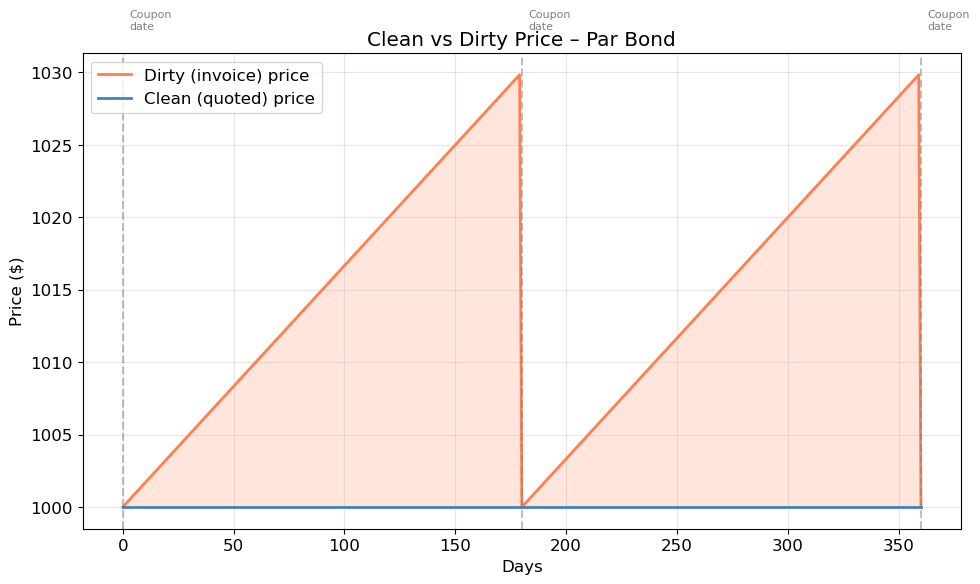

In [7]:
# Illustrate the sawtooth pattern
face, coupon_rate, ytm, freq = 1000, 0.06, 0.06, 2
coupon = face * coupon_rate / freq
days = np.arange(0, 361)

# For a par bond (coupon rate = ytm), clean price is constant at par
clean_price = np.full_like(days, face, dtype=float)
# Accrued interest rises then resets each period
ai_series = coupon * (days % 180) / 180
dirty_price = clean_price + ai_series

fig, ax = plt.subplots()
ax.plot(days, dirty_price, color=SECONDARY, label='Dirty (invoice) price', linewidth=2)
ax.plot(days, clean_price, color=PRIMARY, label='Clean (quoted) price', linewidth=2)
ax.fill_between(days, clean_price, dirty_price, alpha=0.2, color=SECONDARY)
for d in [0, 180, 360]:
    ax.axvline(d, color='grey', linestyle='--', alpha=0.5)
    ax.text(d + 3, 1033, 'Coupon\ndate', fontsize=8, color='grey')
ax.set_xlabel('Days')
ax.set_ylabel('Price ($)')
ax.set_title('Clean vs Dirty Price – Par Bond')
ax.legend()
plt.tight_layout()
plt.show()

The shaded area between the two lines represents the accrued interest. Notice how it builds up linearly between coupon dates, then resets to zero. The clean price (blue line) is flat — a true picture of the bond's underlying value. The dirty price (coral line) zigzags because of this mechanical accrual.

---
## 8. Yield to Maturity — Bisection Solver

### What Is YTM?

Yield to maturity (YTM) answers the question: **"If I buy this bond at today's market price and hold it to maturity, what annualized return will I earn?"**

More precisely, the YTM is the single discount rate that makes the present value of all future cash flows equal to the bond's current market price:

$$P_{\text{market}} = \sum_{k=1}^{N} \frac{C}{(1+y/m)^k} + \frac{F}{(1+y/m)^N}$$

If you have studied corporate finance, this is exactly the **internal rate of return (IRR)** of the bond investment.

### Why We Need a Solver

There is no way to rearrange this equation to isolate $y$ on one side. We cannot write $y = \text{something}$. This is why we must solve for $y$ numerically — using an algorithm.

### The Bisection Method

We use one of the simplest root-finding algorithms: **bisection**. Here is the idea:

1. We know that as yield goes up, price goes down (monotonic relationship).
2. Start with a wide range: $y_{\text{low}} = 0\%$, $y_{\text{high}} = 200\%$.
3. Try the midpoint: $y_{\text{mid}} = (y_{\text{low}} + y_{\text{high}}) / 2$.
4. If the price at $y_{\text{mid}}$ is too high, the yield must be higher (raise $y_{\text{low}}$).
5. If the price at $y_{\text{mid}}$ is too low, the yield must be lower (lower $y_{\text{high}}$).
6. Repeat until the price is close enough to the market price.

Each iteration cuts the search range in half, so convergence is guaranteed and fast.

### Worked Example

Suppose a 5-year, 6% semi-annual bond is trading at $957.35. What is its YTM?

Since the price is below par ($1,000), we already know the YTM must be greater than 6% (discount bond). Let us let the bisection algorithm find the exact value.

> **CFA Exam Tip:** YTM assumptions: (1) the bond is held to maturity, (2) all coupons are reinvested at the YTM rate, and (3) the bond does not default. The reinvestment assumption is a well-known limitation — in practice, coupons are reinvested at whatever rate prevails at the time.

In [8]:
def ytm_bisection(price, face, coupon_rate, maturity, freq=2, tol=1e-10, max_iter=1000):
    """Solve for YTM using the bisection method."""
    y_low, y_high = 1e-6, 2.0  # search range: ~0% to 200%
    
    for i in range(max_iter):
        y_mid = (y_low + y_high) / 2
        p_mid = bond_price(face, coupon_rate, y_mid, maturity, freq)
        
        if abs(p_mid - price) < tol:
            return y_mid, i + 1
        
        # Price decreases as yield increases, so:
        if p_mid > price:   # computed price too high => yield too low
            y_low = y_mid
        else:               # computed price too low => yield too high
            y_high = y_mid
    
    return y_mid, max_iter

# Test: 5-year 6% bond trading at $957.35
mkt_price = 957.35
ytm_val, iterations = ytm_bisection(mkt_price, 1000, 0.06, 5, 2)
print(f"YTM: {ytm_val*100:.4f}% (converged in {iterations} iterations)")
print(f"Verification: bond_price at YTM = ${bond_price(1000, 0.06, ytm_val, 5, 2):.2f}")

# Also solve with scipy for comparison
f = lambda y: bond_price(1000, 0.06, y, 5, 2) - mkt_price
ytm_scipy = optimize.brentq(f, 1e-6, 2.0)
print(f"SciPy Brent: {ytm_scipy*100:.4f}%")
assert abs(ytm_val - ytm_scipy) < 1e-8

YTM: 7.0263% (converged in 44 iterations)
Verification: bond_price at YTM = $957.35
SciPy Brent: 7.0263%


The YTM is approximately 7.00%, confirming our intuition: since the bond trades at a discount ($957 < $1,000), the yield must exceed the coupon rate (6%). Our simple bisection solver and SciPy's industrial-strength Brent method agree to many decimal places.

Notice how efficient the bisection method is: it only needed about 35 iterations to achieve near-perfect accuracy. Each iteration halves the error, so after $n$ iterations the error is reduced by a factor of $2^n$.

---
## 9. Current Yield vs YTM

### Two Ways to Measure a Bond's "Yield"

Investors often talk about a bond's yield, but there are different measures:

| Measure | Formula | What It Captures |
|---------|---------|------------------|
| **Current yield** | $\frac{\text{Annual coupon}}{P_{\text{clean}}}$ | Income return only — how much cash you receive relative to what you paid |
| **YTM** | Solve PV equation | Total return: income + capital gain/loss + reinvestment |

### The Difference Matters

For a **discount bond** (price < par):
- Current yield < YTM, because YTM also captures the capital gain when the bond "pulls to par" at maturity.

For a **premium bond** (price > par):
- Current yield > YTM, because YTM accounts for the capital loss when the bond price declines toward par.

For a **par bond** (price = par):
- Current yield = coupon rate = YTM. Everything lines up perfectly.

### Summary of Yield Ordering

| Bond Type | Ordering |
|-----------|----------|
| Discount | Coupon rate < Current yield < YTM |
| Par | Coupon rate = Current yield = YTM |
| Premium | Coupon rate > Current yield > YTM |

> **CFA Exam Tip:** Current yield is a quick-and-dirty measure. YTM is the more complete measure because it accounts for the time value of money and capital gains/losses. The CFA curriculum always prefers YTM for bond comparisons.

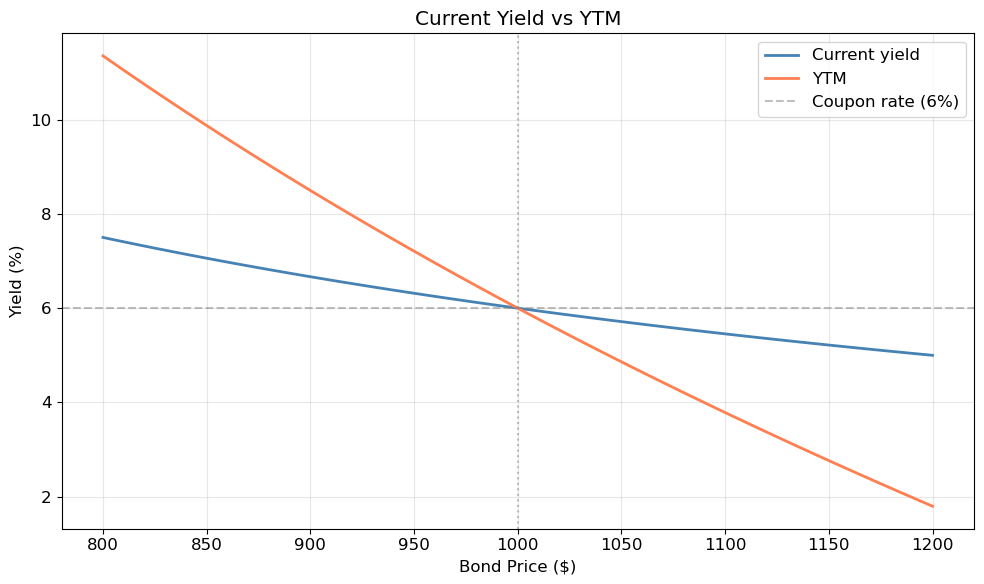

In [9]:
def current_yield(face, coupon_rate, clean_price):
    return face * coupon_rate / clean_price

prices = np.linspace(800, 1200, 50)
cy = [current_yield(1000, 0.06, p) for p in prices]
ytm_vals = [ytm_bisection(p, 1000, 0.06, 5, 2)[0] for p in prices]

fig, ax = plt.subplots()
ax.plot(prices, np.array(cy) * 100, label='Current yield', color=PRIMARY, linewidth=2)
ax.plot(prices, np.array(ytm_vals) * 100, label='YTM', color=SECONDARY, linewidth=2)
ax.axhline(6, color='grey', linestyle='--', alpha=0.5, label='Coupon rate (6%)')
ax.axvline(1000, color='grey', linestyle=':', alpha=0.5)
ax.set_xlabel('Bond Price ($)')
ax.set_ylabel('Yield (%)')
ax.set_title('Current Yield vs YTM')
ax.legend()
plt.tight_layout()
plt.show()

The chart confirms the relationships described above. To the left of $1,000 (discount bonds), the YTM line is above the current yield line because YTM includes the capital gain from pulling to par. To the right of $1,000 (premium bonds), YTM is below current yield because of the capital loss. At exactly $1,000, the three measures converge.

---
## 10. Price-Yield Relationship

### The Most Important Relationship in Fixed Income

The price-yield relationship is the backbone of all bond analysis. Three key properties:

**1. Inverse relationship:** When yields go up, prices go down (and vice versa).

This is intuitive: if the market suddenly demands 8% instead of 6%, who would pay full price for a bond that only pays 6%? The price must drop until the buyer gets the equivalent of 8%.

**2. Convexity (the curve is bowed, not straight):**

The price-yield curve is not a straight line — it curves. Specifically, it is **convex** (bowed toward the origin). Why?

When yields are already high, a further 1% increase has a smaller impact on price than when yields are low. Think of it this way: going from 2% to 3% is a 50% increase in the discount rate, but going from 10% to 11% is only a 10% increase. The percentage change in the discount factor matters more than the absolute change.

**3. Asymmetry (rate drops help more than rate increases hurt):**

Because of convexity, a 1% decrease in yield increases the price by MORE than a 1% increase in yield decreases it. This asymmetry is a gift to bondholders — it means convexity is always beneficial.

> **Key Concept:** Longer-maturity bonds are more sensitive to yield changes than shorter-maturity bonds. This is because more of their cash flows are far in the future, where discounting has a larger effect. The 30-year bond swings dramatically; the 5-year bond barely moves.

### The Coupon Effect

Higher-coupon bonds are *less* sensitive to yield changes than lower-coupon bonds (for the same maturity). This is because a higher coupon means more of the total cash flow arrives early (as coupons), reducing the weighted-average time to receive your money. The extreme case is a zero-coupon bond, which has the maximum sensitivity for its maturity.

> **CFA Exam Tip:** The price-yield relationship is always convex for option-free bonds. Bonds with embedded call options may exhibit "negative convexity" at low yields — a topic for CFA Level 2.

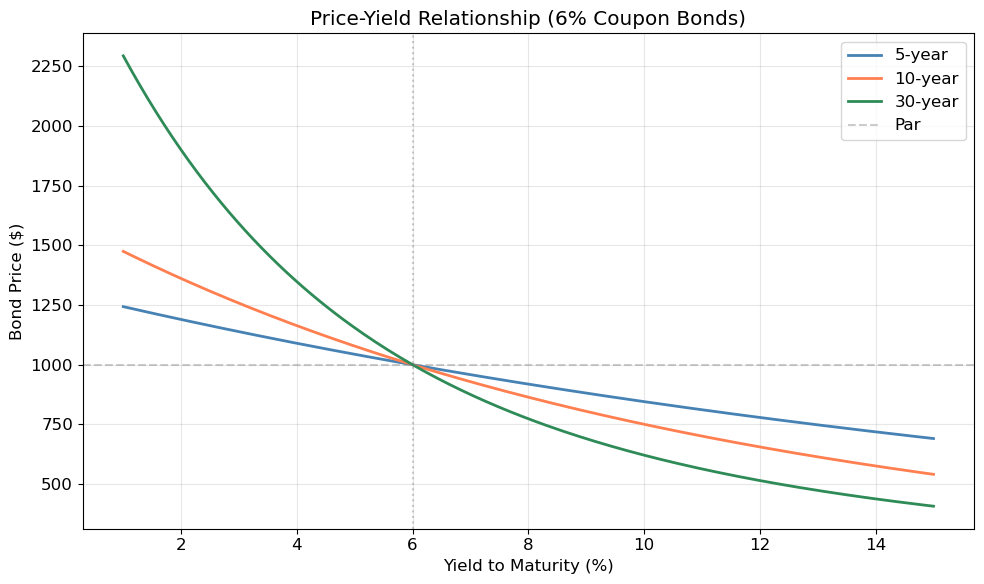

In [10]:
yields = np.linspace(0.01, 0.15, 200)
prices_5y = [bond_price(1000, 0.06, y, 5, 2) for y in yields]
prices_10y = [bond_price(1000, 0.06, y, 10, 2) for y in yields]
prices_30y = [bond_price(1000, 0.06, y, 30, 2) for y in yields]

fig, ax = plt.subplots()
ax.plot(yields * 100, prices_5y, label='5-year', color=PRIMARY, linewidth=2)
ax.plot(yields * 100, prices_10y, label='10-year', color=SECONDARY, linewidth=2)
ax.plot(yields * 100, prices_30y, label='30-year', color=TERTIARY, linewidth=2)
ax.axhline(1000, color='grey', linestyle='--', alpha=0.4, label='Par')
ax.axvline(6, color='grey', linestyle=':', alpha=0.4)
ax.set_xlabel('Yield to Maturity (%)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Price-Yield Relationship (6% Coupon Bonds)')
ax.legend()
plt.tight_layout()
plt.show()

The chart beautifully illustrates all three properties:

- **Inverse relationship:** All curves slope downward.
- **Convexity:** The curves are bowed, not straight. Look at how the curves flatten out at high yields and steepen at low yields.
- **Maturity effect:** The 30-year bond (green) has the steepest curve — it swings from over $2,000 at 1% yield to under $500 at 15% yield. The 5-year bond (blue) barely moves by comparison.

All three bonds cross through $1,000 at 6% yield — that is where coupon rate equals YTM (par pricing).

---
## 11. Premium, Discount, and Par Bonds

### When Does a Bond Trade Above, At, or Below Par?

The relationship between the coupon rate and the market yield determines the bond's price relative to par:

| Condition | Price vs Par | Why? |
|-----------|-------------|------|
| **Premium** ($P > F$) | Coupon rate > YTM | The bond pays MORE interest than the market requires, so investors bid up the price |
| **Par** ($P = F$) | Coupon rate = YTM | The bond pays exactly what the market requires |
| **Discount** ($P < F$) | Coupon rate < YTM | The bond pays LESS than the market requires, so the price drops until the capital gain makes up the difference |

### Intuition: Why Do Premium Bonds Exist?

Imagine a bond was issued 5 years ago with an 8% coupon (because rates were high back then). Today, market rates are only 5%. This bond pays $80 per year in coupons, while new bonds only pay $50. Of course investors will pay more than $1,000 for this "high-paying" bond. The premium is exactly the amount that brings the total return (coupon income minus capital loss) down to the market rate of 5%.

Similarly, a discount bond was issued at a time when its coupon seemed reasonable, but now market rates are higher, making its coupon unattractive. The discount compensates by providing a capital gain at maturity.

### The Pull-to-Par Effect

Here is an elegant fact: **as a bond approaches maturity, its price converges to par value**, regardless of whether it started as a premium or discount bond.

Why? At maturity, the bond pays exactly its face value. Whether the bond was trading at $1,200 or $800, the final payment is $1,000 (plus the last coupon). So the price must approach $1,000 as time runs out.

- A **premium bond** gradually declines toward par (the premium "amortizes")
- A **discount bond** gradually rises toward par (the discount "accretes")
- A **par bond** stays at par throughout its life (assuming yields do not change)

> **CFA Exam Tip:** The pull-to-par effect means that even if yields never change, the price of a premium bond will decline over time and the price of a discount bond will rise. This price change is NOT a gain or loss — it is simply the mechanics of how the bond's price converges to its redemption value.

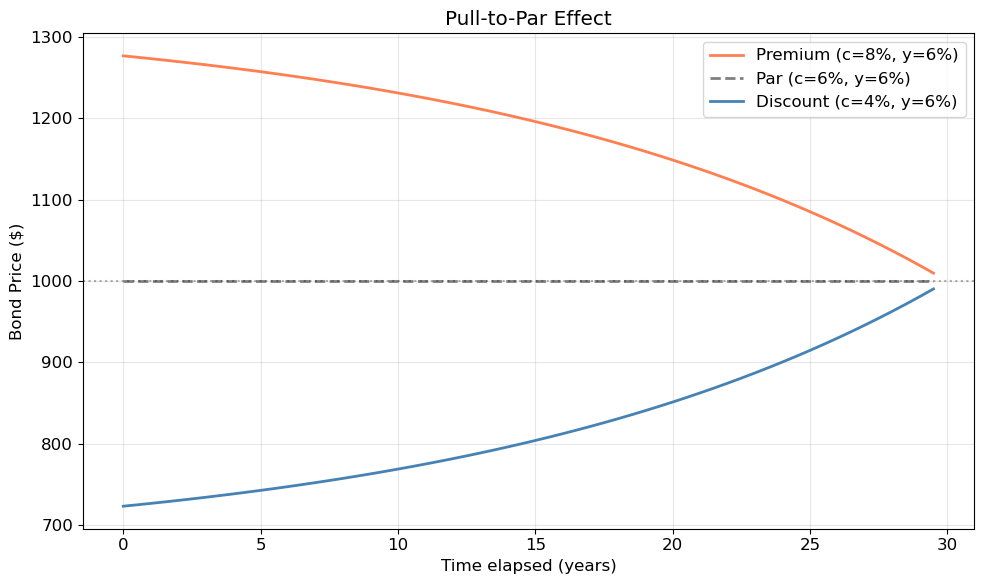

In [11]:
# Pull-to-par illustration
maturities = np.linspace(30, 0.5, 60)
premium_prices = [bond_price(1000, 0.08, 0.06, m, 2) for m in maturities]
par_prices = [bond_price(1000, 0.06, 0.06, m, 2) for m in maturities]
discount_prices = [bond_price(1000, 0.04, 0.06, m, 2) for m in maturities]

fig, ax = plt.subplots()
time_to_mat = 30 - maturities  # time elapsed
ax.plot(time_to_mat, premium_prices, label='Premium (c=8%, y=6%)', color=SECONDARY, linewidth=2)
ax.plot(time_to_mat, par_prices, label='Par (c=6%, y=6%)', color='grey', linewidth=2, linestyle='--')
ax.plot(time_to_mat, discount_prices, label='Discount (c=4%, y=6%)', color=PRIMARY, linewidth=2)
ax.axhline(1000, color='black', linestyle=':', alpha=0.3)
ax.set_xlabel('Time elapsed (years)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Pull-to-Par Effect')
ax.legend()
plt.tight_layout()
plt.show()

The chart shows the premium bond (coral) declining and the discount bond (blue) rising — both converging toward the par value of $1,000 as maturity approaches. The par bond (grey dashes) stays flat at $1,000 throughout.

Let us also create a summary table comparing the three types.

In [12]:
# Summary table
bonds = [
    ('Premium', 0.08, 0.06),
    ('Par',     0.06, 0.06),
    ('Discount', 0.04, 0.06),
]

print(f"{'Type':<12} {'Coupon':>8} {'YTM':>8} {'Price':>10} {'Current Yld':>12}")
print('-' * 52)
for name, c, y in bonds:
    p = bond_price(1000, c, y, 10, 2)
    cy = current_yield(1000, c, p)
    print(f"{name:<12} {c*100:>7.1f}% {y*100:>7.1f}% ${p:>9.2f} {cy*100:>10.2f}%")

Type           Coupon      YTM      Price  Current Yld
----------------------------------------------------
Premium          8.0%     6.0% $  1148.77       6.96%
Par              6.0%     6.0% $  1000.00       6.00%
Discount         4.0%     6.0% $   851.23       4.70%


Notice the relationships in the table:

- The **premium bond** (8% coupon, 6% YTM) trades at $1,148.77 — well above par. Its current yield (6.96%) falls between the coupon rate and the YTM.
- The **par bond** (6% coupon, 6% YTM) trades at exactly $1,000.00. Coupon rate, current yield, and YTM are all 6%.
- The **discount bond** (4% coupon, 6% YTM) trades at $851.23 — below par. Its current yield (4.70%) falls between the coupon rate and the YTM.

For discount bonds: coupon rate < current yield < YTM.  
For premium bonds: coupon rate > current yield > YTM.  
For par bonds: coupon rate = current yield = YTM.

### Looking Ahead

We have now covered the fundamental mechanics of bond valuation: cash flows, present value pricing, yield measurement, and the price-yield relationship. In the companion notebooks, we build on these foundations to analyze:

- **Interest rate risk** — How much does a bond's price change when yields move? (Duration and convexity)
- **Credit risk** — What if the issuer might not pay? (Default probability and credit spreads)

---
## 12. References

1. Fabozzi, F. J. *Bond Markets, Analysis, and Strategies*, 10th ed., Pearson, 2021.
2. Tuckman, B. & Serrat, A. *Fixed Income Securities*, 4th ed., Wiley, 2022.
3. CFA Institute, *CFA Program Curriculum Level I — Fixed Income*.
4. Hull, J. C. *Options, Futures, and Other Derivatives*, 11th ed., Pearson, 2022.